RQ1 (Binary): Can introducing semantically valid, artificially crafted, and maliciously altered network flow perturbations, creating the effects of a network poisoning attack, into an IDS training dataset reduce the robustness of a binary-classification XGBoost IDS model trained on the Unified Multimodal NIDS CIC-IDS2019 dataset?

H10: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model's training dataset has no statistically significant effect on the binary model's overall performance.

H1a: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model's training dataset has a statistically significant effect on the binary model's overall performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
df_sample = pd.read_csv("data/clean_sample_150000.csv")

# Consolidate DoS_ATTACK and NON_DoS_ATTACK into a single ATTACK class
df_sample["label"] = df_sample["label"].map(
    {"BENIGN": 0, "DoS_ATTACK": 1, "NON_DoS_ATTACK": 1}
)

X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]

CLASS_NAMES = ["BENIGN", "ATTACK"]
print("Class distribution:")
print(y.value_counts())

Class distribution:
label
1    100000
0     50000
Name: count, dtype: int64


In [3]:
def base_xgb():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
    )

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")
y_test  = y_test.reset_index(drop=True).to_numpy()

model = base_xgb()
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
DECISION_THRESHOLD = 0.7

def predict_binary_threshold(model, X, threshold):
    return (model.predict_proba(X)[:, 1] >= threshold).astype(int)

print(f"Decision threshold: {DECISION_THRESHOLD}")

In [ ]:
y_prob = model.predict_proba(X_test)
y_pred = predict_binary_threshold(model, X_test, DECISION_THRESHOLD)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob[:, 1]))

In [6]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     10000
      ATTACK       1.00      1.00      1.00     20000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



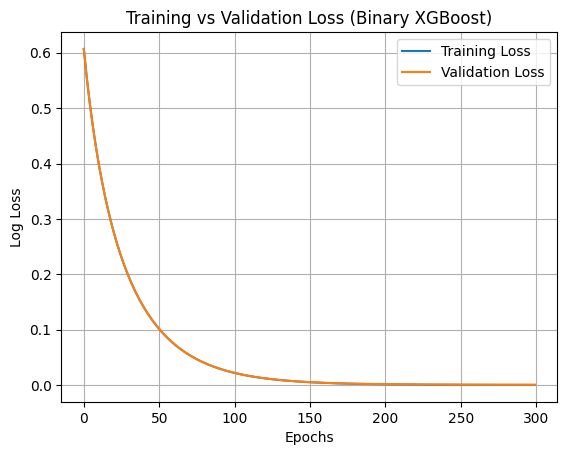

In [7]:
evals = model.evals_result()
train_loss = evals["validation_0"]["logloss"]
val_loss   = evals["validation_1"]["logloss"]
plt.figure()
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss,   label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss (Binary XGBoost)")
plt.legend()
plt.grid()
plt.show()

In [8]:
# Identify ATTACK samples nearest the decision boundary (lowest P(ATTACK))
proba_train = model.predict_proba(X_train)
y_train_arr = y_train.reset_index(drop=True).to_numpy()
attack_mask   = y_train_arr == 1
atk_idx       = np.where(attack_mask)[0]
atk_X         = X_train.reset_index(drop=True).iloc[atk_idx]
atk_y         = y_train_arr[atk_idx]
atk_proba     = proba_train[atk_idx, 1]          # P(ATTACK); lower = closer to boundary
order         = np.argsort(atk_proba)            # ascending: least confident first
boundary_X    = atk_X.iloc[order].reset_index(drop=True)
boundary_y    = atk_y[order]
boundary_conf = atk_proba[order]

boundary_df = boundary_X.copy()
boundary_df["true_label"] = boundary_y
boundary_df["confidence"] = boundary_conf
boundary_df.to_csv("data/boundary_attacks_binary.csv", index=False)
print(f"Saved {len(boundary_df):,} boundary-adjacent attack samples")
print(f"P(ATTACK) range      : {boundary_conf.min():.4f} – {boundary_conf.max():.4f}")
print(f"Bottom-10% threshold : {np.percentile(boundary_conf, 10):.4f}")
print("\nAverage confidence by class:")
all_conf = proba_train[np.arange(len(y_train_arr)), y_train_arr]
for cls_val, cls_name in enumerate(CLASS_NAMES):
    cls_mask = y_train_arr == cls_val
    print(f"  {cls_name:<8}: avg={all_conf[cls_mask].mean():.4f}  (n={cls_mask.sum():,})")

Saved 80,000 boundary-adjacent attack samples
P(ATTACK) range      : 0.0880 – 1.0000
Bottom-10% threshold : 1.0000

Average confidence by class:
  BENIGN  : avg=0.9998  (n=40,000)
  ATTACK  : avg=0.9999  (n=80,000)


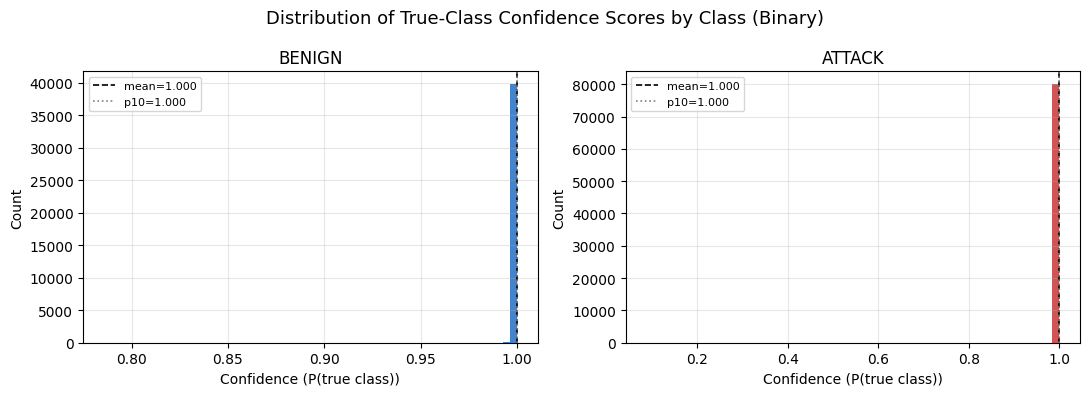

Saved confidence_distribution_binary.png


In [9]:
cls_colors_bin = ["#1565C0", "#C62828"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Distribution of True-Class Confidence Scores by Class (Binary)", fontsize=13)

for cls_val, cls_name in enumerate(CLASS_NAMES):
    cls_mask = y_train_arr == cls_val
    scores   = all_conf[cls_mask]
    ax = axes[cls_val]
    ax.hist(scores, bins=60, color=cls_colors_bin[cls_val], alpha=0.8, edgecolor="none")
    ax.axvline(scores.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"mean={scores.mean():.3f}")
    ax.axvline(np.percentile(scores, 10), color="grey", linestyle=":", linewidth=1.2,
               label=f"p10={np.percentile(scores, 10):.3f}")
    ax.set_title(cls_name)
    ax.set_xlabel("Confidence (P(true class))")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("confidence_distribution_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved confidence_distribution_binary.png")

In [10]:
def load_perturbation_csv(path):
    """Load a perturbation CSV, drop label/pred columns, remap labels to binary."""
    df = pd.read_csv(path)
    drop_cols = ["true_label", "y_pred", "pred_clean", "pred_adv", "target_class", "fooled"]
    X_p = (
        df.drop(columns=drop_cols, errors="ignore")
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .fillna(0)
          .reindex(columns=X_train.columns, fill_value=0)
          .astype("float32")
    )
    y_p = (df["true_label"].reset_index(drop=True).values != 0).astype(int)
    return X_p, y_p

In [ ]:
noise_X, noise_y = load_perturbation_csv("data/noise_epsilon_0.05.csv")
noise_pred = predict_binary_threshold(model, noise_X, DECISION_THRESHOLD)
noise_prob = model.predict_proba(noise_X)
print("── Noise (ε=0.05) ──")
print("Accuracy :", accuracy_score(noise_y, noise_pred))
print("F1       :", f1_score(noise_y, noise_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(noise_y, noise_prob[:, 1]))
print(classification_report(noise_y, noise_pred, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
adv_X, adv_y = load_perturbation_csv("data/adversarial_epsilon_0.05.csv")
adv_pred = predict_binary_threshold(model, adv_X, DECISION_THRESHOLD)
adv_prob = model.predict_proba(adv_X)
print("── FGSM Adversarial (ε=0.05) ──")
print("Accuracy :", accuracy_score(adv_y, adv_pred))
print("F1       :", f1_score(adv_y, adv_pred, zero_division=0))
try:
    print("ROC-AUC  :", roc_auc_score(adv_y, adv_prob[:, 1]))
except ValueError:
    print("ROC-AUC  : n/a (y_true is single-class after binary remap)")
print(classification_report(adv_y, adv_pred, target_names=CLASS_NAMES,
                             labels=[0, 1], zero_division=0))

In [ ]:
hsj_X, hsj_y = load_perturbation_csv("data/adversarial_hsj_xgb.csv")
hsj_pred = predict_binary_threshold(model, hsj_X, DECISION_THRESHOLD)
hsj_prob = model.predict_proba(hsj_X)
print("── HopSkipJump ──")
print("Accuracy :", accuracy_score(hsj_y, hsj_pred))
print("F1       :", f1_score(hsj_y, hsj_pred, zero_division=0))
try:
    print("ROC-AUC  :", roc_auc_score(hsj_y, hsj_prob[:, 1]))
except ValueError:
    print("ROC-AUC  : n/a (y_true is single-class after binary remap)")
print(classification_report(hsj_y, hsj_pred, target_names=CLASS_NAMES,
                             labels=[0, 1], zero_division=0))

In [ ]:
boundary_pred = predict_binary_threshold(model, boundary_X, DECISION_THRESHOLD)
boundary_prob = model.predict_proba(boundary_X)
print("── Boundary-adjacent attacks ──")
print(f"Samples: {len(boundary_X):,}  class dist: {dict(zip(*np.unique(boundary_y, return_counts=True)))}")
print("Accuracy :", accuracy_score(boundary_y, boundary_pred))
print("F1       :", f1_score(boundary_y, boundary_pred, zero_division=0))
try:
    print("ROC-AUC  :", roc_auc_score(boundary_y, boundary_prob[:, 1]))
except ValueError:
    print("ROC-AUC  : n/a (y_true is single-class after binary remap)")
print(classification_report(boundary_y, boundary_pred, target_names=CLASS_NAMES,
                             labels=[0, 1], zero_division=0))

Running t-SNE on 2454 samples...


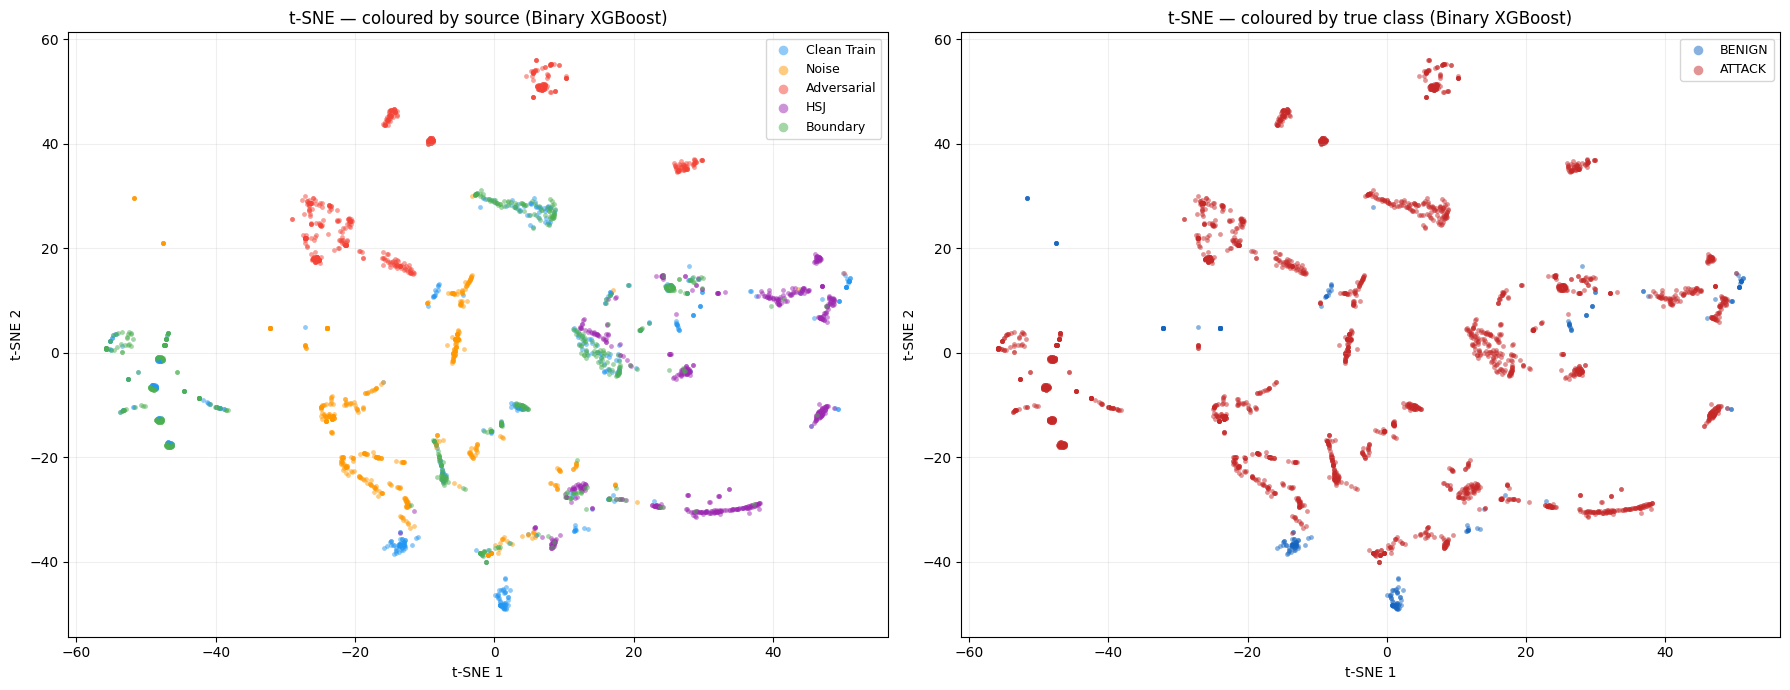

Saved tsne_xgboost_binary.png


In [15]:
N_TSNE   = 500
rng_tsne = np.random.default_rng(42)
cols     = X_train.columns.tolist()

sources_tsne = {
    "Clean Train": (X_train.reset_index(drop=True),   y_train.reset_index(drop=True).to_numpy()),
    "Noise":       (noise_X.reset_index(drop=True),   noise_y),
    "Adversarial": (adv_X.reset_index(drop=True),     adv_y),
    "HSJ":         (hsj_X.reset_index(drop=True),     hsj_y),
    "Boundary":    (boundary_X.reset_index(drop=True), boundary_y),
}

all_X_tsne, all_source, all_class = [], [], []
for src_name, (sx, sy) in sources_tsne.items():
    n   = min(N_TSNE, len(sx))
    idx = rng_tsne.choice(len(sx), size=n, replace=False)
    sx_arr = sx[cols].values if hasattr(sx, "columns") else sx
    all_X_tsne.append(sx_arr[idx])
    all_source.extend([src_name] * n)
    all_class.extend(sy[idx].tolist())

all_X_tsne = np.vstack(all_X_tsne).astype(np.float32)
all_source  = np.array(all_source)
all_class   = np.array(all_class)

print(f"Running t-SNE on {len(all_X_tsne)} samples...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=-1)
Z    = tsne.fit_transform(all_X_tsne)

src_order  = ["Clean Train", "Noise", "Adversarial", "HSJ", "Boundary"]
src_colors = {"Clean Train": "#2196F3", "Noise": "#FF9800", "Adversarial": "#F44336",
              "HSJ": "#9C27B0", "Boundary": "#4CAF50"}
cls_colors = {0: "#1565C0", 1: "#C62828"}
cls_labels = {0: "BENIGN", 1: "ATTACK"}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for src in src_order:
    mask = all_source == src
    ax.scatter(Z[mask, 0], Z[mask, 1], c=src_colors[src], label=src,
               alpha=0.5, s=12, linewidths=0)
ax.set_title("t-SNE — coloured by source (Binary XGBoost)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
for cls in [0, 1]:
    mask = all_class == cls
    ax.scatter(Z[mask, 0], Z[mask, 1], c=cls_colors[cls],
               label=cls_labels[cls], alpha=0.5, s=12, linewidths=0)
ax.set_title("t-SNE — coloured by true class (Binary XGBoost)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("tsne_xgboost_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved tsne_xgboost_binary.png")

In [16]:
def poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate, random_state=42):
    ae_X = ae_X.reindex(columns=X_train.columns, fill_value=0)
    rng  = np.random.default_rng(random_state)
    n_total  = len(X_train)
    n_poison = int(n_total * poison_rate)
    X_clean  = X_train.reset_index(drop=True).copy()
    y_clean  = y_train.reset_index(drop=True).to_numpy().copy()

    if n_poison == 0:
        idx = rng.permutation(n_total)
        return X_clean.iloc[idx].reset_index(drop=True), y_clean[idx]

    # Draw poisoning samples from attack class only; mislabel them as BENIGN
    ae_X_attacks = ae_X[ae_y == 1].reset_index(drop=True)
    chosen   = rng.choice(len(ae_X_attacks), size=n_poison,
                          replace=(n_poison > len(ae_X_attacks)))
    X_poison = ae_X_attacks.iloc[chosen].reset_index(drop=True).copy()
    y_poison = np.zeros(n_poison, dtype=int)

    # Proportionally drop n_poison samples from the clean training set
    keep_mask = np.ones(n_total, dtype=bool)
    classes, counts = np.unique(y_clean, return_counts=True)
    fracs    = counts / n_total
    drop_per = np.floor(fracs * n_poison).astype(int)
    remainder = n_poison - drop_per.sum()
    for i in np.argsort(-fracs)[:remainder]:
        drop_per[i] += 1
    for i, cls in enumerate(classes):
        cls_idx = np.where(y_clean == cls)[0]
        n_drop  = min(drop_per[i], len(cls_idx))
        keep_mask[rng.choice(cls_idx, size=n_drop, replace=False)] = False

    keep_idx = np.where(keep_mask)[0]
    X_kept   = X_clean.iloc[keep_idx].reset_index(drop=True)
    y_kept   = y_clean[keep_idx]

    X_poisoned = pd.concat([X_kept, X_poison], ignore_index=True)
    y_poisoned = np.concatenate([y_kept, y_poison])
    idx = rng.permutation(len(X_poisoned))
    return X_poisoned.iloc[idx].reset_index(drop=True), y_poisoned[idx]

In [17]:
def fpr_benign(y_true, y_pred):
    """Fraction of ATTACK samples misclassified as BENIGN (attack miss rate)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    attack_mask = y_true == 1
    if attack_mask.sum() == 0:
        return 0.0
    missed = np.sum(y_pred[attack_mask] == 0)
    return float(missed) / (attack_mask.sum() + 1e-10)

In [ ]:
thresholds = np.arange(0.05, 0.99, 0.01)
fprs, recalls = [], []
for t in thresholds:
    y_pred_t = predict_binary_threshold(model, X_test, t)
    fprs.append(fpr_benign(y_test, y_pred_t))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
fprs, recalls = np.array(fprs), np.array(recalls)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(thresholds, recalls, color="#1565C0", label="Recall (ATTACK)")
ax.plot(thresholds, fprs,    color="#C62828", label="Attack Miss Rate (FPR)")
ax.axvline(DECISION_THRESHOLD, color="grey", linestyle="--", linewidth=1, label=f"threshold ({DECISION_THRESHOLD})")
ax.set_xlabel("P(ATTACK) Threshold")
ax.set_ylabel("Score")
ax.set_title("Recall & Attack Miss Rate vs Threshold")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(fprs, recalls, color="#2E7D32", linewidth=1.5)
default_idx = np.argmin(np.abs(thresholds - DECISION_THRESHOLD))
ax.scatter(fprs[default_idx], recalls[default_idx], color="grey", zorder=5, label=f"threshold ({DECISION_THRESHOLD})")
for t_mark in [0.2, 0.3, 0.4, 0.6, 0.7, 0.8]:
    idx = np.argmin(np.abs(thresholds - t_mark))
    ax.annotate(f"{t_mark}", (fprs[idx], recalls[idx]),
                textcoords="offset points", xytext=(4, 4), fontsize=7)
    ax.scatter(fprs[idx], recalls[idx], s=20, color="#2E7D32", zorder=5)
ax.set_xlabel("Attack Miss Rate (FPR)")
ax.set_ylabel("Recall (ATTACK)")
ax.set_title("FPR–Recall Tradeoff (P(ATTACK) threshold sweep)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("threshold_sweep_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved threshold_sweep_binary.png")

In [19]:
GROUPS = {
    "Control (0%)":       0.00,
    "Experiment 1 (5%)": 0.05,
    "Experiment 2 (10%)": 0.10,
    "Experiment 3 (15%)": 0.15,
    "Experiment 4 (20%)": 0.20,
    "Experiment 5 (25%)": 0.25,
    "Experiment 6 (30%)": 0.30,
    "Experiment 7 (35%)": 0.35,
    "Experiment 8 (40%)": 0.40,
    "Experiment 9 (45%)": 0.45,
    "Experiment 10 (50%)": 0.50,
}

N_BOOTSTRAPS = 500

In [ ]:
SOURCES = [
    ("Noise",       noise_X,    noise_y),
    ("Adversarial", adv_X,      adv_y),
    ("HSJ",         hsj_X,      hsj_y),
    ("Boundary",    boundary_X, boundary_y),
]

all_results = {s: [] for s, *_ in SOURCES}
group_preds = {s: {} for s, *_ in SOURCES}

boot_idx = [resample(np.arange(len(y_test)), replace=True) for _ in range(N_BOOTSTRAPS)]

for source_name, ae_X, ae_y in SOURCES:
    print(f"\n{'='*60}")
    print(f"  {source_name.upper()}")
    print(f"{'='*60}")
    for group_name, poison_rate in GROUPS.items():
        X_tr, y_tr = poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate)
        exp_model  = base_xgb()
        exp_model.fit(X_tr, y_tr)
        y_pred_exp = predict_binary_threshold(exp_model, X_test, DECISION_THRESHOLD)
        group_preds[source_name][group_name] = y_pred_exp

        acc  = accuracy_score(y_test, y_pred_exp)
        prec = precision_score(y_test, y_pred_exp, zero_division=0)
        rec  = recall_score(y_test, y_pred_exp, zero_division=0)
        f1   = f1_score(y_test, y_pred_exp, zero_division=0)
        fpr  = fpr_benign(y_test, y_pred_exp)
        roc  = roc_auc_score(y_test, exp_model.predict_proba(X_test)[:, 1])

        acc_b, prec_b, rec_b, f1_b, fpr_b = [], [], [], [], []
        for idx in boot_idx:
            acc_b.append(accuracy_score(y_test[idx], y_pred_exp[idx]))
            prec_b.append(precision_score(y_test[idx], y_pred_exp[idx], zero_division=0))
            rec_b.append(recall_score(y_test[idx], y_pred_exp[idx], zero_division=0))
            f1_b.append(f1_score(y_test[idx], y_pred_exp[idx], zero_division=0))
            fpr_b.append(fpr_benign(y_test[idx], y_pred_exp[idx]))

        def ci(vals): return np.percentile(vals, 2.5), np.percentile(vals, 97.5)

        all_results[source_name].append({
            "Group":       group_name,
            "Poison Rate": poison_rate,
            "Accuracy":    round(acc,  4),  "Acc CI":  ci(acc_b),
            "Precision":   round(prec, 4),  "Prec CI": ci(prec_b),
            "Recall":      round(rec,  4),  "Rec CI":  ci(rec_b),
            "F1":          round(f1,   4),  "F1 CI":   ci(f1_b),
            "Attack Miss": round(fpr,  4),  "FPR CI":  ci(fpr_b),
            "ROC-AUC":     round(roc,  4),
        })
        print(f"  {group_name:<24}  F1={f1:.4f}  Recall={rec:.4f}  Miss={fpr:.4f}  AUC={roc:.4f}")

In [ ]:
for source_name, results in all_results.items():
    print(f"\n\n══ {source_name.upper()} — SUMMARY WITH 95% BOOTSTRAP CIs ══")
    summary = pd.DataFrame([{
        "Group":       r["Group"],
        "Poison %":    f"{int(r['Poison Rate']*100)}%",
        "Accuracy":    f"{r['Accuracy']} [{r['Acc CI'][0]:.4f}, {r['Acc CI'][1]:.4f}]",
        "Precision":   f"{r['Precision']} [{r['Prec CI'][0]:.4f}, {r['Prec CI'][1]:.4f}]",
        "Recall":      f"{r['Recall']} [{r['Rec CI'][0]:.4f}, {r['Rec CI'][1]:.4f}]",
        "F1":          f"{r['F1']} [{r['F1 CI'][0]:.4f}, {r['F1 CI'][1]:.4f}]",
        "Attack Miss": f"{r['Attack Miss']} [{r['FPR CI'][0]:.4f}, {r['FPR CI'][1]:.4f}]",
        "ROC-AUC":     r["ROC-AUC"],
    } for r in results])
    display(summary)

    print(f"\n══ {source_name.upper()} — BOOTSTRAP p-VALUES vs CONTROL ══")
    ctrl_pred = group_preds[source_name]["Control (0%)"]
    hyp_rows  = []
    for group_name, poison_rate in GROUPS.items():
        if poison_rate == 0.0:
            continue
        exp_pred = group_preds[source_name][group_name]
        diffs    = []
        for _ in range(N_BOOTSTRAPS):
            idx = resample(np.arange(len(y_test)), replace=True)
            diffs.append(
                f1_score(y_test[idx], ctrl_pred[idx], zero_division=0) -
                f1_score(y_test[idx], exp_pred[idx],  zero_division=0)
            )
        diffs = np.array(diffs)
        p = min(np.mean(diffs <= 0), np.mean(diffs >= 0)) * 2
        hyp_rows.append({
            "Comparison":   f"Control vs {group_name}",
            "Mean F1 Drop": round(np.mean(diffs), 4),
            "95% CI":       f"[{np.percentile(diffs,2.5):.4f}, {np.percentile(diffs,97.5):.4f}]",
            "p-value":      round(p, 6),
            "Significant":  "Yes" if p < 0.05 else "No",
        })
    display(pd.DataFrame(hyp_rows))

In [ ]:
poison_labels = [f"{int(v*100)}%" for v in GROUPS.values()]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle("Per-Class Recall vs Poison Rate (Binary XGBoost)", fontsize=14)

for ax, source_name in zip(axes, [s for s, *_ in SOURCES]):
    per_class_recall = {c: [] for c in CLASS_NAMES}
    for group_name in GROUPS:
        y_pred_g = group_preds[source_name][group_name]
        for i, cls in enumerate(CLASS_NAMES):
            mask = y_test == i
            per_class_recall[cls].append(
                np.mean(y_pred_g[mask] == i) if mask.sum() > 0 else np.nan
            )
    for cls in CLASS_NAMES:
        ax.plot(poison_labels, per_class_recall[cls], marker="o", label=cls)
    ax.set_title(source_name)
    ax.set_xlabel("Poison Rate")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for source_name, *_ in SOURCES:
    print(f"\n══ {source_name.upper()} — PER-CLASS RECALL ══")
    rows = []
    for group_name, poison_rate in GROUPS.items():
        y_pred_g = group_preds[source_name][group_name]
        row = {"Group": group_name, "Poison Rate": f"{int(poison_rate*100)}%"}
        for i, cls in enumerate(CLASS_NAMES):
            mask = y_test == i
            row[f"Recall ({cls})"] = (
                round(np.mean(y_pred_g[mask] == i), 4) if mask.sum() > 0 else np.nan
            )
        rows.append(row)
    display(pd.DataFrame(rows))